### **Supervised Machine Learning**


- Supervised Machine Learning is a type of machine learning that learns the relationship between input and output.

- In Supervised Machine Learning, the relationship between the input and labeled output is learnt through the process of training
- Two types of Supervised Machine Learning :
  -  Classification
  -  Regression

- **Classification** is a type of supervised machine learning where the model learns from the data to predict a discrete event or an outcome
    - Logistic Regression, XGBoost Classifier are some of the many machine learning algorithms for a classification problem

- **Regression** is a type of supervised machine learning where the model learns from the data to predict continuous values such as weight.
    - Linear Regression, Gradient Boosted Trees Regression are some of the many machine learning algorithms for a regression problem


*Reference:*


*Géron, Aurélien. "Hands-on machine learning with Scikit-Learn." Keras, and TensorFlow: Concepts, tools, and techniques to build intelligent systems 1 (2019).*


### **Problem statement**



- Pyspark is an interface for Apache Spark, providing a way to interactively look at the data in a distributed environment

- Supports features including Spark SQL, DataFrame, ML pipeline, etc.,

- The task is a classification problem - for predicting the stability of electric grid.

- The dataset for this problem can be found at : https://archive.ics.uci.edu/dataset/471/electrical+grid+stability+simulated+data






### **Importing required libraries**



In [9]:
  # Importing the os module
  import os

  # Setting up Spark environment variable  - Install OpenJDK environment to run spark
  !apt-get install openjdk-11-jdk-headless -qq > /dev/null

  # Download Apache Spark 3.5.0 with hadoop quietly
  !wget -q https://archive.apache.org/dist/spark/spark-3.5.1/spark-3.5.1-bin-hadoop3.tgz

  # Extract the Spark package
  !tar xf spark-3.5.1-bin-hadoop3.tgz

  # Set JAVA_HOME environment path pointing to where OpenJDK is installed
  os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"

  # Set SPARK_HOME environment path pointing to where Spark is installed
  os.environ["SPARK_HOME"] = "/content/spark-3.5.1-bin-hadoop3"


In [10]:
# list the contents of the current working directory

!ls

sample_data  spark-3.5.1-bin-hadoop3  spark-3.5.1-bin-hadoop3.tgz


In [11]:
#Installing findspark package, necessary to run Spark from Jupyter Notebook
!pip install findspark --quiet

# Importing findspark Library
import findspark

In [12]:
# Initializing Pyspark - locates spark installation

findspark.init()

### **A higher level and a slightly more straight forward approach for Spark installation**


In [13]:
!pip install pyspark

In [14]:
# Installing xgboost library for this classification problem

!pip install xgboost --quiet

### **Importing Dependencies**

In [15]:
# Importing SparkSession from pyspark.sql to create Spark entry points

from pyspark.sql import SparkSession

In [16]:
# Calling the builder method and getOrCreate to create or
# retrieve a Spark session
# Spark runs locally with available cores

spark = SparkSession.builder \
        .master("local[*]") \
        .appName("My Spark Application") \
        .getOrCreate()


In [17]:
# Elements of the created SparkSession

spark

In [18]:
# Importing required libraries from pyspark.sql for data manipulation and
# modeling

# Libraries for data manipulation

from pyspark.sql.functions import col, when, count, isnan, round
import pandas as pd

# library for advanced data visualization
import seaborn as sns

# Libaries for the Classification model
from xgboost.spark import SparkXGBClassifier
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

In [19]:
# Installing pytictoc for monitoring time elapsed during code execution
!pip install pytictoc --quiet

In [20]:
# Importing TicToc class from pytictoc for the timing functionality
from pytictoc import TicToc

### **Importing the dataset**

In [21]:
# Dependencies to import required files from google drive to google - colab environment

from google.colab import drive

In [22]:
drive.mount('/content/drive')

Mounted at /content/drive


In [23]:
# Importing the dataset 'stabf_class.csv' to a dataframe

df = spark.read.csv('/content/drive/MyDrive/Stabf_class.csv', header = True,inferSchema = "true")

### **Data understanding and data cleaning**

In [24]:
# Count the distinct values in the stabf - output feature
df.select(['stabf']).distinct().count()

2

In [25]:
# Count of null values in the columns in the dataframe
# using isNull(), isnan() and verify if there are 'NaN',
# 'NULL' or empty string ""

df2 = df.select([count(when(col(c).contains('None') | \
                      col(c).contains('NaN') | \
                      col(c).contains('NULL') | \
                      (col(c) == "") | \
                      (col(c).isNull()) | \
                       isnan(c), c)).alias(c) for c in df.columns])

df2.show()

+----+----+----+----+---+---+---+---+---+---+---+---+-----+
|tau1|tau2|tau3|tau4| p1| p2| p3| p4| g1| g2| g3| g4|stabf|
+----+----+----+----+---+---+---+---+---+---+---+---+-----+
|   0|   0|   0|   0|  0|  0|  0|  0|  0|  0|  0|  0|    0|
+----+----+----+----+---+---+---+---+---+---+---+---+-----+



In [26]:
# Display the shape of the dataset with df.count() method and
# df.columns attribute

print("Shape of the dataset : ", (df.count(),len(df.columns)))

Shape of the dataset :  (6460, 13)


In [27]:
# Verify presence of duplicate rows in the dataframe with df.distinct() method

DistinctDF = df.distinct()

str(DistinctDF.count())

'6460'

### **Description of the dataset**

In [28]:
# Generate basic Descriptive statistics for 'Electric_grid.csv' with df.describe() method

df.describe().show()

+-------+------------------+-----------------+------------------+-----------------+------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+------------------+--------+
|summary|              tau1|             tau2|              tau3|             tau4|                p1|                 p2|                 p3|                 p4|                 g1|                 g2|                 g3|                g4|   stabf|
+-------+------------------+-----------------+------------------+-----------------+------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+------------------+--------+
|  count|              6460|             6460|              6460|             6460|              6460|               6460|               6460|               6460|               6460|               6460|               6460|              6460|    64

In [29]:
# Display the schema of the DataFrame, which shows it in a tree format

df.printSchema()

root
 |-- tau1: double (nullable = true)
 |-- tau2: double (nullable = true)
 |-- tau3: double (nullable = true)
 |-- tau4: double (nullable = true)
 |-- p1: double (nullable = true)
 |-- p2: double (nullable = true)
 |-- p3: double (nullable = true)
 |-- p4: double (nullable = true)
 |-- g1: double (nullable = true)
 |-- g2: double (nullable = true)
 |-- g3: double (nullable = true)
 |-- g4: double (nullable = true)
 |-- stabf: string (nullable = true)



### **Converting to a Pandas DataFrame**

To facilitate visualization of the DataFrame with Seaborn, it is essential to convert the PySpark DataFrame to a Pandas DataFrame - since PySpark doesn't natively support Seaborn for visualizations



In [30]:
# Conversion of the PySpark dataframe to a Pandas dataframe

df_pandas = df.toPandas()

In [31]:
# Extracting the ratio of categories in the output column

df_pandas['stabf'].value_counts(normalize = True)

stabf
stable      0.504799
unstable    0.495201
Name: proportion, dtype: float64

<Axes: xlabel='stabf', ylabel='count'>

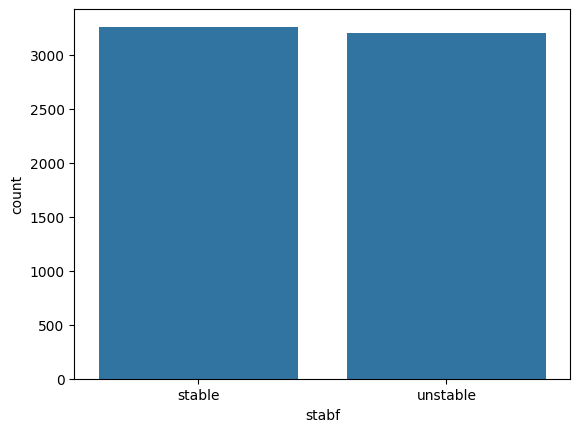

In [32]:
# Visualizing the 'stabf' column in the form of a count plot with Seaborn Library

sns.countplot(data = df_pandas, x = "stabf")

### **Data Preparation for XGBoost Model**

In [33]:
# Use of StringIndexer from pyspark.ml.feature
# maps the output column (label) to label indices with .fit() and .transform()
# returns a dataframe

string_indexer = StringIndexer(inputCol = "stabf", outputCol = "stabf_category")
df_indexed = string_indexer.fit(df).transform(df)

In [34]:
# Datatype of each column in df_indexed dataframe
df_indexed.dtypes

[('tau1', 'double'),
 ('tau2', 'double'),
 ('tau3', 'double'),
 ('tau4', 'double'),
 ('p1', 'double'),
 ('p2', 'double'),
 ('p3', 'double'),
 ('p4', 'double'),
 ('g1', 'double'),
 ('g2', 'double'),
 ('g3', 'double'),
 ('g4', 'double'),
 ('stabf', 'string'),
 ('stabf_category', 'double')]

In [35]:
# Display the first 10 rows of the df_indexed dataframe

df_indexed.show(n=10)

+-----------------+----------------+-----------------+----------------+----------------+------------------+------------------+------------------+-----------------+------------------+-----------------+------------------+--------+--------------+
|             tau1|            tau2|             tau3|            tau4|              p1|                p2|                p3|                p4|               g1|                g2|               g3|                g4|   stabf|stabf_category|
+-----------------+----------------+-----------------+----------------+----------------+------------------+------------------+------------------+-----------------+------------------+-----------------+------------------+--------+--------------+
|  9.3040972346785|4.90252411201167| 3.04754072762177|1.36935735529605|5.06781210427845| -1.94005842705193| -1.87274168559721| -1.25501199162931| 0.41344056837935| 0.862414076352903|0.562139050527675| 0.781759910653126|  stable|           0.0|
| 8.97170690932022|8.848

### **Vector Assembler**

In [36]:
# Importing Vector Assembler to merge input features into a vector- column
# for the xgboost classifier model

from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(inputCols=["tau1", "tau2", "tau3", "tau4", "p1", "p2", "p3", "p4", "g1", "g2", "g3", "g4"],outputCol = "features")

In [37]:
# Applying the assembler.transform() method to create a dataframe with combined features in a vector-column
# Includes specified input columns and the output 'features' column

df_transformed = assembler.transform(df_indexed)

In [38]:
df_transformed.show(5)

+-----------------+----------------+----------------+----------------+----------------+------------------+------------------+------------------+-----------------+------------------+-----------------+-----------------+--------+--------------+--------------------+
|             tau1|            tau2|            tau3|            tau4|              p1|                p2|                p3|                p4|               g1|                g2|               g3|               g4|   stabf|stabf_category|            features|
+-----------------+----------------+----------------+----------------+----------------+------------------+------------------+------------------+-----------------+------------------+-----------------+-----------------+--------+--------------+--------------------+
|  9.3040972346785|4.90252411201167|3.04754072762177|1.36935735529605|5.06781210427845| -1.94005842705193| -1.87274168559721| -1.25501199162931| 0.41344056837935| 0.862414076352903|0.562139050527675|0.7817599106

In [39]:
# Displaying the first five rows of the "features" column

df_transformed.select("features").show(truncate=False, n=5)

+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|features                                                                                                                                                                                                              |
+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|[9.3040972346785,4.90252411201167,3.04754072762177,1.36935735529605,5.06781210427845,-1.94005842705193,-1.87274168559721,-1.25501199162931,0.41344056837935,0.862414076352903,0.562139050527675,0.781759910653126]    |
|[8.97170690932022,8.84842842134833,3.04647874898866,1.21451813833956,3.40515818001095,-1.20745559234302,-1.27721014673295,-0.920492

### **XGBoost**

- XGBoost : Extreme Gradient Boosting is a scalable, optimized, distributed gradient boosting technique

- Gradient Boosting combines multiple weak learners (such as decision trees) to collectively form a strong predictor

- The algorithm initially fits a simple model (such as a decision tree) to the data.

- The residual from this model is then used to train a second model, which is subsequently added to the ensemble.

- This process repeats several times with each subsequent model trained on the residual from the previous model

- The final predictor is the sum of all the models in the ensemble

- https://xgboost.readthedocs.io/en/stable/


In [40]:
# Initializing SparkXGBClassifier with the input features and the 'stabf' output column
# gpu for computation

xgb = SparkXGBClassifier(features_col="features", label_col = "stabf_category", device = "gpu")

In [41]:
# Setting the dataframe into a tuple of train and test datasets -  80% for training and 20% for test

(train, test) = df_transformed.randomSplit([0.8, 0.2])

In [42]:
# Setting up the modeling pipeline in Pyspark for the XGBoost Classification Model

pipeline = Pipeline(stages=[xgb])

pipeline

Pipeline_1058c16366a2

In [43]:
# Constructing the Parameter Grid to evaluate different values of
# maxDepth parameter and a value of gamma
# for the XGBoost Classification Model

paramGrid = ParamGridBuilder() \
            .addGrid(xgb.max_depth, [2, 3]) \
            .addGrid(xgb.gamma,[4]) \
            .addGrid(xgb.n_estimators, [10, 70, 100]) \
            .build()

In [44]:
# Initializing the Binary Classification Evaluator to quantify the AUC (Area under the ROC curve)
# score for the XGBoost Classification Model

evaluator = BinaryClassificationEvaluator(metricName = "areaUnderROC", labelCol = "stabf_category", rawPredictionCol = "prediction")

In [45]:
# Initializing the CrossValidator for model tuning and evaluation
# with the defined ParamGrid, evaluator and the model pipeline

Cross_validator = CrossValidator(estimator = pipeline, evaluator = evaluator, estimatorParamMaps = paramGrid, numFolds = 5)

In [46]:
# Training the model with CrossValidator.fit() method
# timing functionality to quantify the time elapsed
t = TicToc()
t.tic()
model = Cross_validator.fit(train)
t.toc()

INFO:XGBoost-PySpark:Running xgboost-2.0.3 on 1 workers with
	booster params: {'device': 'gpu', 'gamma': 4, 'max_depth': 2, 'objective': 'binary:logistic', 'nthread': 1}
	train_call_kwargs_params: {'verbose_eval': True, 'num_boost_round': 10}
	dmatrix_kwargs: {'nthread': 1, 'missing': nan}
INFO:SparkXGBClassifier:Stage-level scheduling in xgboost requires spark standalone or local-cluster mode
INFO:XGBoost-PySpark:Finished xgboost training!
INFO:XGBoost-PySpark:Running xgboost-2.0.3 on 1 workers with
	booster params: {'device': 'gpu', 'gamma': 4, 'max_depth': 2, 'objective': 'binary:logistic', 'nthread': 1}
	train_call_kwargs_params: {'verbose_eval': True, 'num_boost_round': 70}
	dmatrix_kwargs: {'nthread': 1, 'missing': nan}
INFO:SparkXGBClassifier:Stage-level scheduling in xgboost requires spark standalone or local-cluster mode
INFO:XGBoost-PySpark:Finished xgboost training!
INFO:XGBoost-PySpark:Running xgboost-2.0.3 on 1 workers with
	booster params: {'device': 'gpu', 'gamma': 4, 'm

Elapsed time is 146.503190 seconds.


In [47]:
 # Making predictions on the training dataset with model.transform() method

response_1 = model.transform(train)

In [48]:
# Calculation of AUC metric for the training set

auc_train = format(evaluator.evaluate(response_1), ".2f")
auc_train

'0.96'

In [49]:
# Making Predictions on the test dataset with the model.transform() method

response= model.transform(test)

In [50]:
# Calculating the AUC metric for the model

auc_test = format(evaluator.evaluate(response), ".2f")
auc_test

'0.92'